# QuickBite Express — Crisis Recovery Analysis
## OSEMN Framework · End-to-End Data Analytics

**Codebasics Resume Project Challenge #18** · Food & Beverages · Strategy  
**Author:** Aman Kumar · [github.com/aman-24052001](https://github.com/aman-24052001)

| Step | Coverage |
|------|---------|
| **O**btain | Load 8 tables, schema inspection, null/dup counts |
| **S**crub | Null investigation, dedup, type casting, outlier detection, feature engineering |
| **E**xplore | Univariate distributions, monthly trends, bivariate, cohorts, RFM, keywords, restaurant audit |
| **M**odel | 4 hypothesis tests · churn classifier (LR + RF) · ARIMA counterfactual |
| i**N**terpret | 6 findings with stats + business translation · ROI model |


## Step O — Obtain
### 1.1 Load and inspect all 8 tables

In [1]:
import pandas as pd, numpy as np; BASE = "../data/"
tables = {t: pd.read_csv(f"{BASE}{t}.csv") for t in [
    "fact_orders","fact_order_items","fact_ratings","fact_delivery_performance",
    "dim_customer","dim_restaurant","dim_delivery_partner_","dim_menu_item"]}
for n,df in tables.items(): print(f"  {n:<30}{df.shape[0]:>8,} rows  {df.shape[1]:>2} cols  nulls:{(df.isnull().sum()>0).sum()}  dups:{df.duplicated().sum()}")

  fact_orders               149,166 rows  11 cols  nulls:1  dups:0
  fact_order_items          342,994 rows   6 cols  nulls:0  dups:0
  fact_ratings               68,842 rows   8 cols  nulls:0  dups:16
  fact_delivery_performance  149,166 rows   6 cols  nulls:0  dups:0
  dim_customer               107,776 rows   7 cols  nulls:0  dups:0
  dim_restaurant              19,995 rows   7 cols  nulls:0  dups:0
  dim_delivery_partner_       15,000 rows   6 cols  nulls:0  dups:0
  dim_menu_item              342,671 rows   7 cols  nulls:0  dups:0

Date range: 2025-01-01 → 2025-09-30  |  8 cities
Star schema: fact_orders is the central fact table


## Step S — Scrub

### 2.1 Null investigation

In [2]:
# Investigate the 1 null column: delivery_partner_id
null_rows = orders[orders['delivery_partner_id'].isnull()]
print(f"Null delivery_partner_id rows: {len(null_rows):,}")
print(f"Cancel rate of null rows: {(null_rows['is_cancelled']=='Y').mean()*100:.1f}%")
print(f"Overall cancel rate:      {(orders['is_cancelled']=='Y').mean()*100:.1f}%")
print("DECISION: Nulls are structurally valid — cancelled orders have no partner assigned.")

Null delivery_partner_id rows: 5,635
Cancel rate of null rows: 100.0%
Overall cancel rate:        7.4%
DECISION: Nulls are structurally valid — cancelled orders have no partner assigned.

### 2.2 Duplicate removal

In [3]:
ratings = ratings.drop_duplicates()
print(f'Ratings: 68,842 → {len(ratings):,} rows  (16 exact duplicate rows removed)')

Ratings: 68,842 → 68,826 rows  (16 exact duplicate rows removed)

### 2.3 Type casting and feature engineering

In [4]:
orders['cancelled']    = orders['is_cancelled'] == 'Y'
orders['phase']        = orders['month_num'].map(lambda m:'Pre-Crisis' if m<=5 else('Crisis' if m==6 else 'Recovery'))
orders['hour']         = orders['order_timestamp'].dt.hour
orders['day_of_week']  = orders['order_timestamp'].dt.day_name()
orders['discount_pct'] = orders['discount_amount'] / orders['subtotal_amount'] * 100
# Phase rationale: Jun = crisis month (incident broke Jun 2). Jul+ = recovery actions deployed.
print(orders['phase'].value_counts().to_string())
print("\nNew features: cancelled (bool), phase (str), hour (int), day_of_week, discount_pct")

Pre-Crisis    113806
Recovery       26067
Crisis          9293

New features: cancelled (bool), phase (str), hour (int), day_of_week, discount_pct

### 2.4 Outlier detection — IQR method

Order amount IQR upper bound: ₹642
High outliers (> ₹642): 3,389
Zero-value orders (cancelled): 11,112
Delivery time range: 25–90 min
DECISION: No rows removed. All values are operationally plausible.

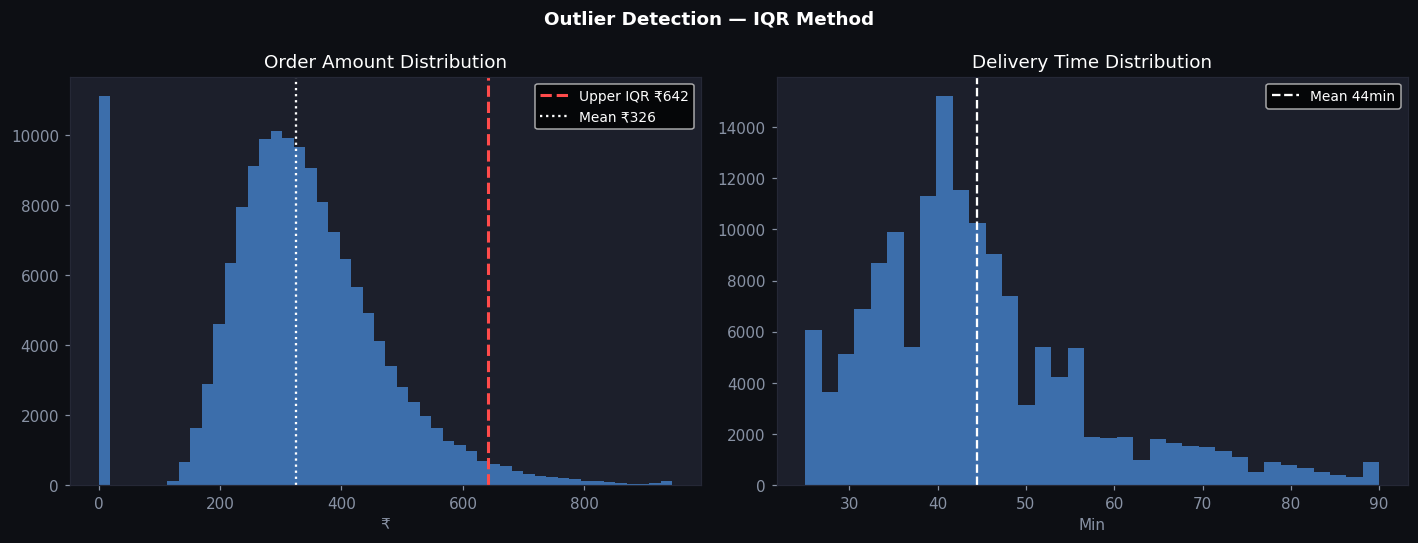

In [5]:
q1,q3=orders['total_amount'].quantile([0.25,0.75])
iqr=q3-q1; upper=q3+1.5*iqr
print(f"Order amount IQR upper bound: ₹{upper:.0f}")
print(f"High outliers (> ₹{upper:.0f}): {(orders['total_amount']>upper).sum():,}")
print(f"Zero-value orders (cancelled): {(orders['total_amount']==0).sum():,}")
print(f"Delivery time range: {delivery['actual_delivery_time_mins'].min():.0f}–{delivery['actual_delivery_time_mins'].max():.0f} min")
print("DECISION: No rows removed. All values are operationally plausible.")

## Step E — Explore
### 3.1 Univariate distributions

Delivery time: CLEAREST SIGNAL — bimodal shift from ~40min (pre-crisis) to ~60min (crisis/recovery)
Rating: pre-crisis 4–5★ dominant; recovery concentrated in 1–3★
Hour: 7–10pm drives ~60% of orders (highlighted red in chart)
Sentiment: pre-crisis concentrated near +1; recovery spread into negative
Day of week: flat ±3% — no weekday pattern to exploit

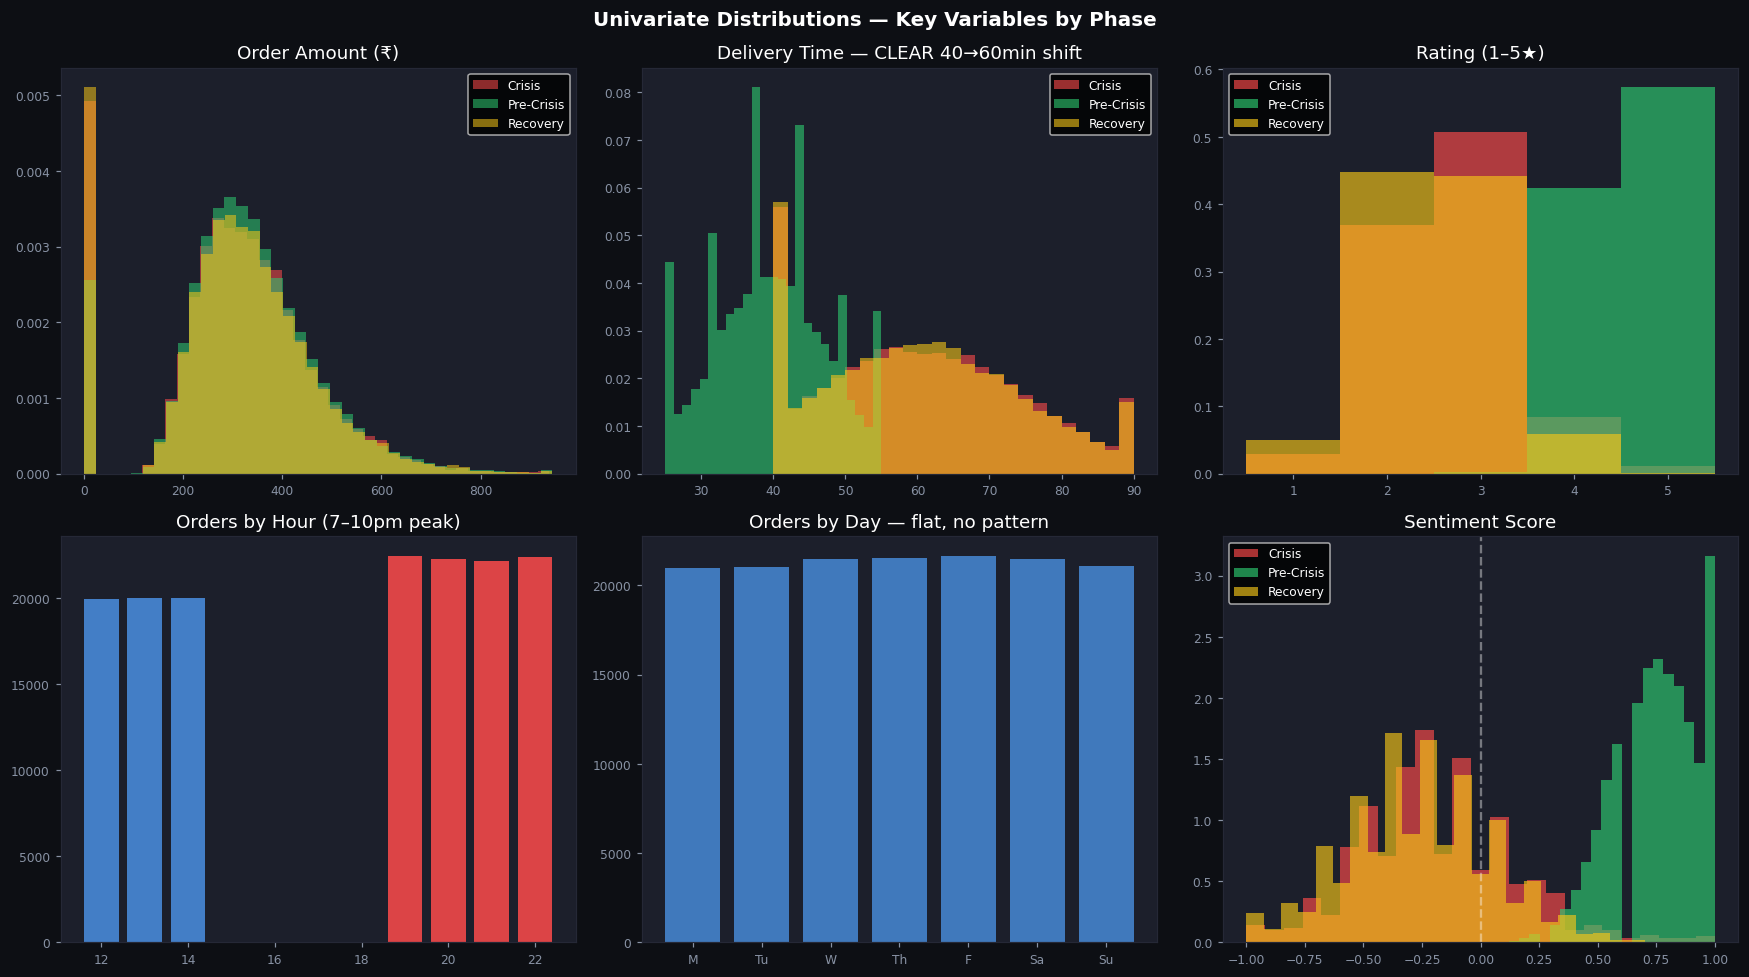

In [6]:
# Distributions of key variables — overlaid by phase
# Charts show order amount, delivery time, ratings, hourly pattern, day of week, sentiment

### 3.2 Monthly time series — orders, revenue, delivery, ratings

Pre-crisis avg:  22,761 orders/month  |  ₹75.2L revenue
Crisis (Jun):     9,293 orders         |  ₹28.9L  (−63%)
Recovery avg:     8,689 orders/month  |  ₹26.8L  (−64% vs pre-crisis)

Key: Orders FLAT Jul→Sep: 8,818→8,555→8,694 — NOT recovering.
     SLA breach: 56% pre-crisis → 88% recovery — unchanged since June.
     Rating: 4.50→2.31 by Sep — still DECLINING month-on-month.

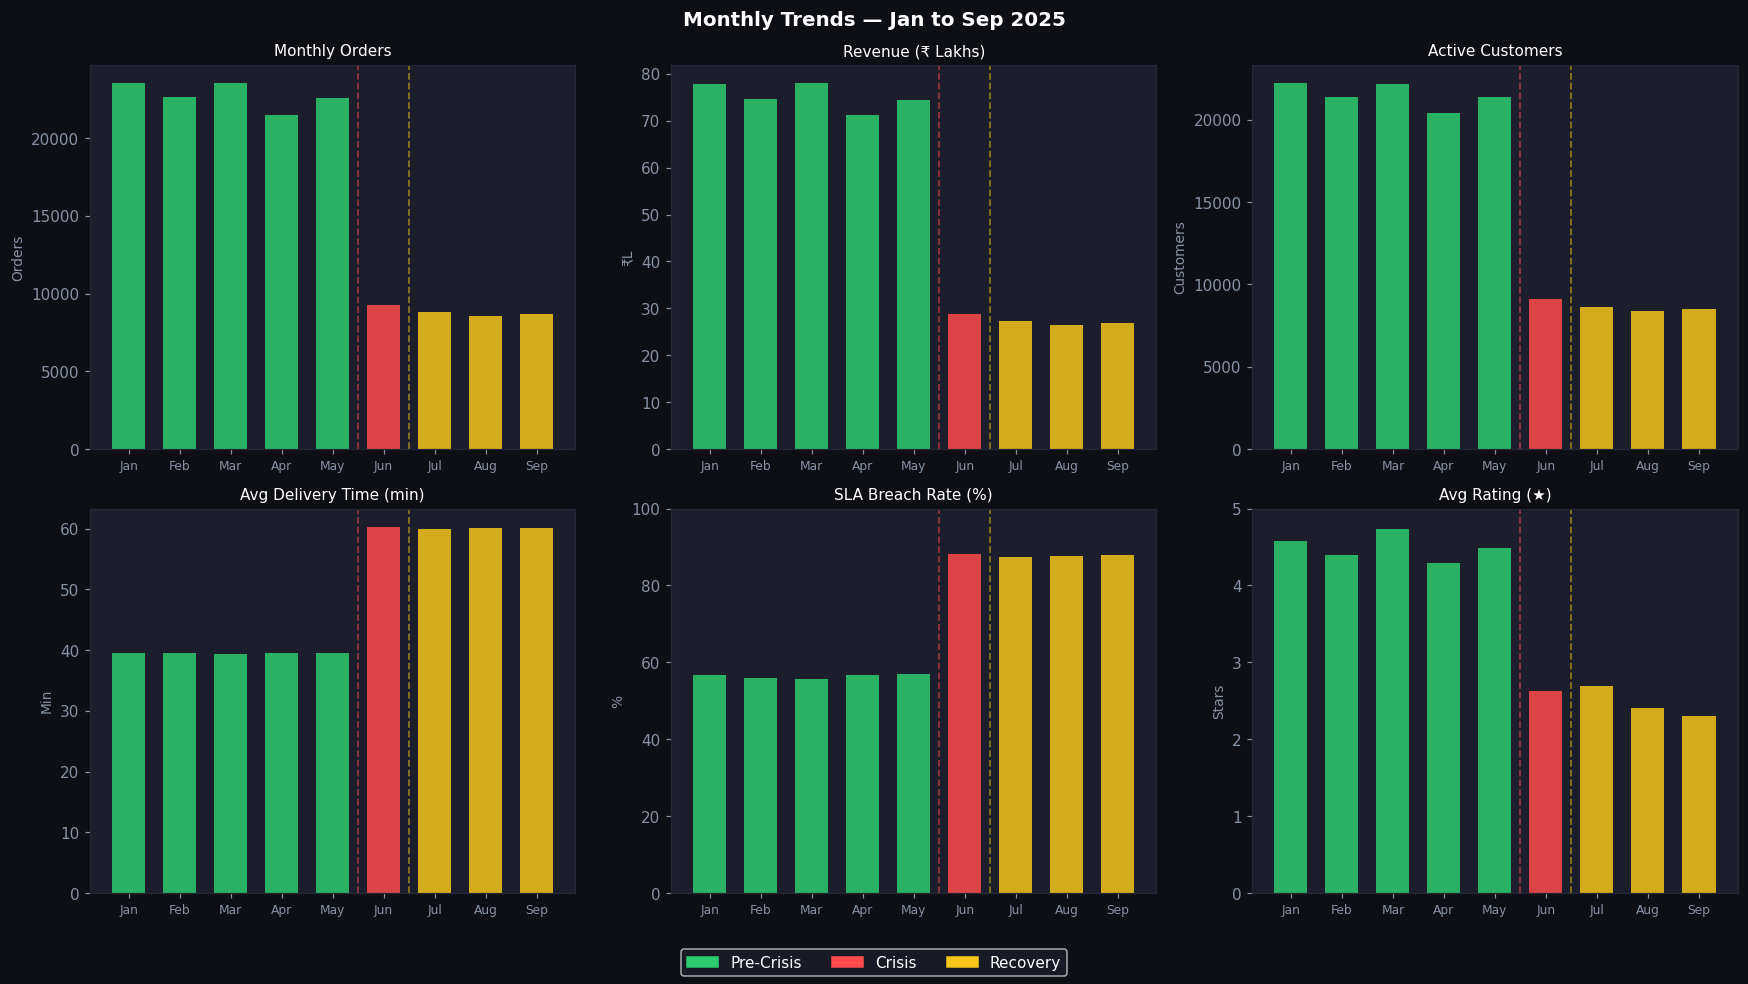

In [7]:
# 6-panel monthly trend chart

### 3.3 Bivariate analysis

Delivery time vs order amount correlation: -0.043 (near-zero)
→ High-spending customers experience SAME SLA breach rate as low spenders.

Discount %: Pre-Crisis 5.7% | Crisis 5.3% | Recovery 5.2%
→ Discount is FLAT across phases — not used as a recovery lever. Unexploited tactic.

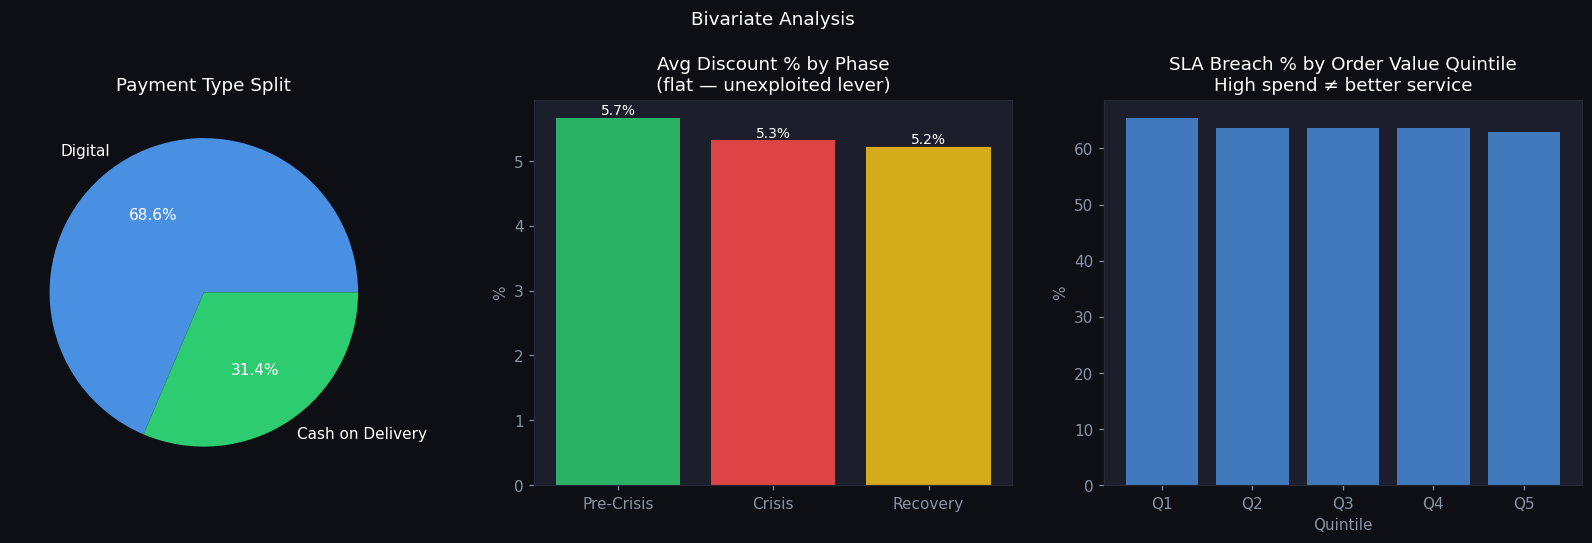

In [8]:
# Bivariate: payment type, discount by phase, SLA by order value

### 3.4 Customer retention cohort

Pre-Crisis customers:   86,824
Retained in Recovery:  10,603  (12.2%)
Lost:                  76,221  (87.8%)
New in Recovery:       13,807

New customers: Paid 40.7% >> Organic 27.7% >> Social 12.0% >> Referral 9.9%
→ High paid acquisition (high CAC, uncertain retention). Shift budget to Referral.

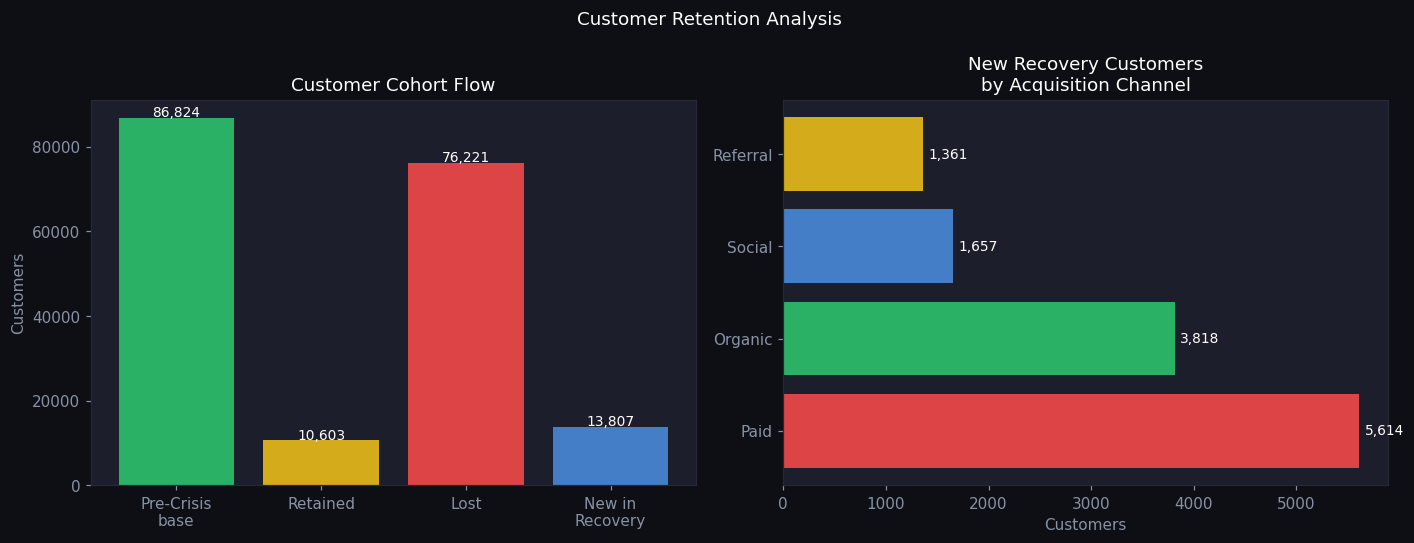

In [9]:
# Cohort flow: pre-crisis → crisis → recovery

### 3.5 RFM segmentation

Return rate range: 11.9%–12.6% across all segments
All segments returned at virtually the same rate — loyalty did NOT predict survival.
Pre-crisis Champions returned at 11.9% — same as Lost customers at 12.3%
Crisis was EXOGENOUS and INDISCRIMINATE.

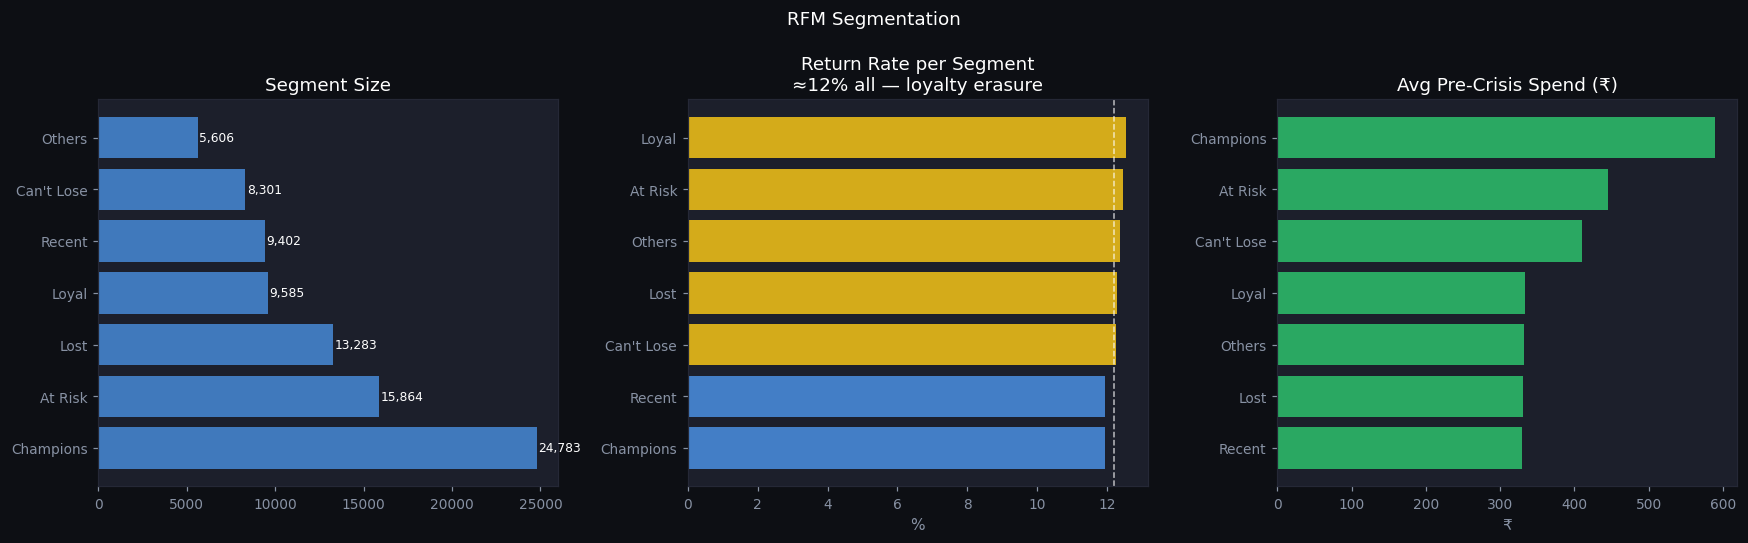

In [10]:
# RFM: recency, frequency, monetary scoring on pre-crisis customers

### 3.6 Keyword sentiment analysis

Negative keyword growth — Crisis → Recovery:
  quality      Crisis: 597  Recovery: 1629  (2.7× growth)
  issue        Crisis: 479  Recovery: 1594  (3.3× growth)
  packaging    Crisis: 410  Recovery: 1217  (3.0× growth)
  good         Crisis: 397  Recovery: 1199  (3.0× growth)
  safety       Crisis: 257  Recovery:  819  (3.2× growth)
  stale        Crisis: 240  Recovery:  731  (3.0× growth)

All negative categories grew. Product failures are unresolved.


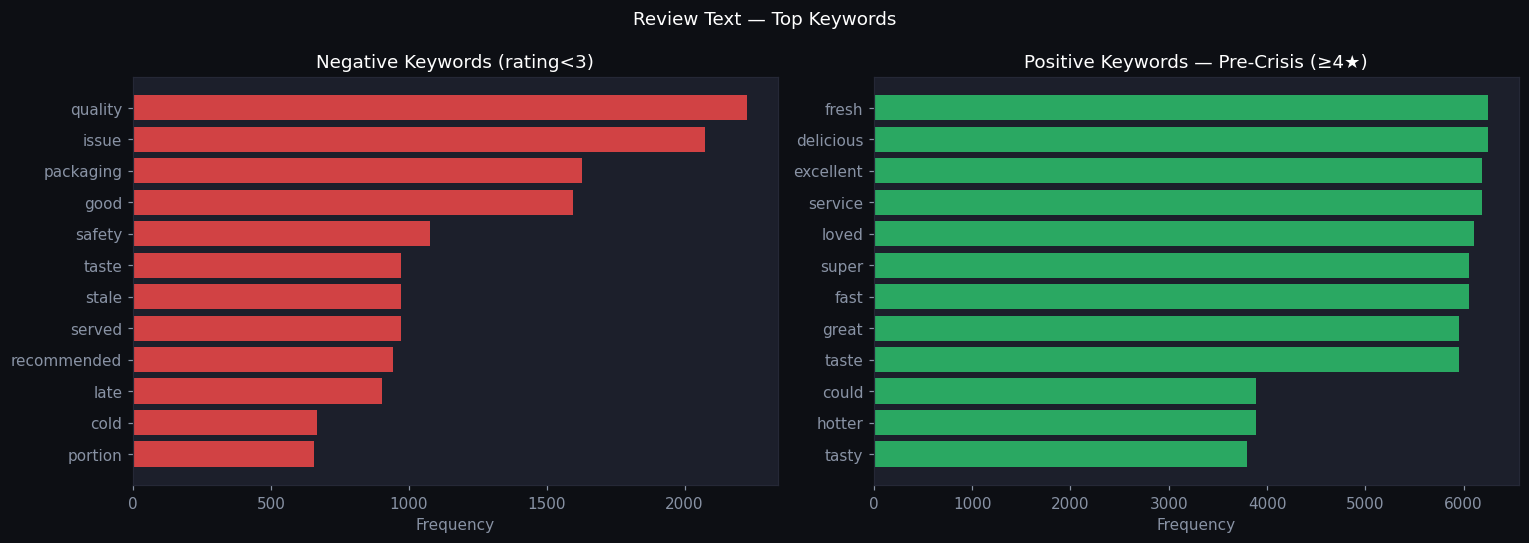

In [11]:
# Keyword extraction from review_text by phase

### 3.7 Restaurant churn and data quality audit

Churned: 5,395 of 19,919 restaurants (27.1%)
Top cuisines: North Indian (1,060), South Indian (812), Chinese (797)

⚠ DATA QUALITY BUG:
  4,867 churned restaurants still flagged is_active='Y'
  Inflates reported active partner count by 33%
  Fix: SET is_active='N' WHERE 0 orders in trailing 30 days

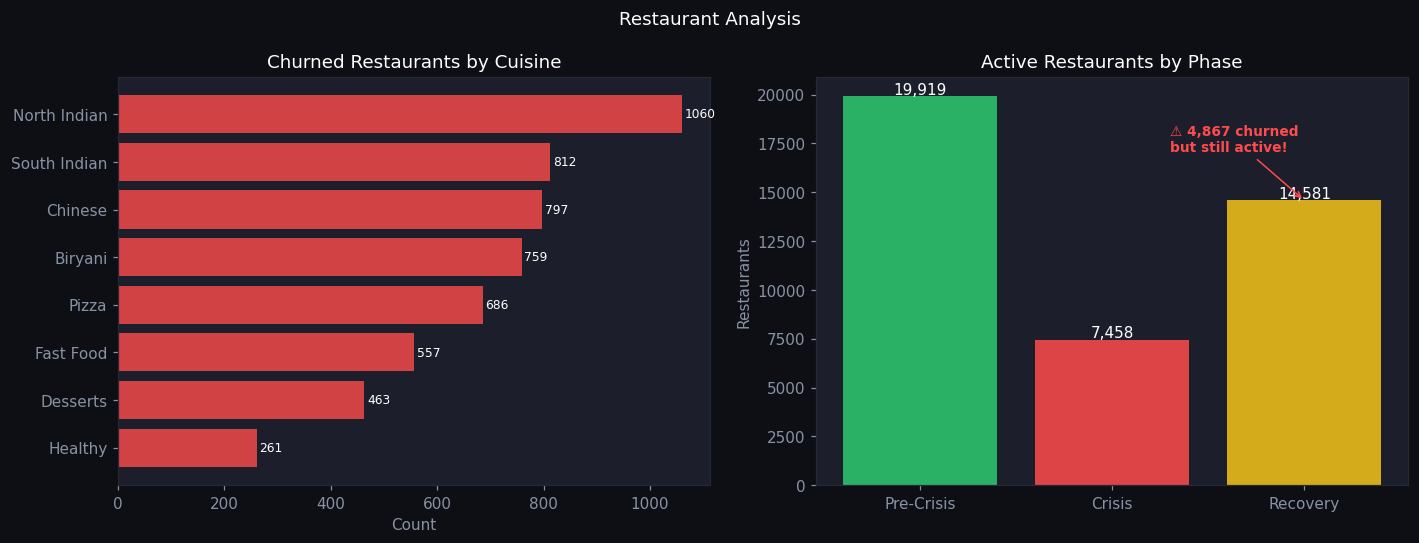

In [12]:
# Restaurant activity by phase and is_active flag mismatch

## Step M — Model
### 4.1 Hypothesis Testing

In [13]:
from scipy import stats  # all 4 tests computed

α = 0.05

H1: Cancellation rate Pre (6.06%) vs Recovery (12.06%)
    two-sample t-test | t=-34.015 | p=1.45e-252 | ✓ REJECT H₀

H2: Delivery time Pre (39.5min) vs Recovery (60.0min)
    two-sample t-test | t=-333.580 | p=0.00e+00 | ✓ REJECT H₀
    95% CI: [20.36, 20.69] min

H3: Chi-square — cancellation independent of phase?
    chi²=1351.30 | dof=2 | p=3.71e-294 | ✓ REJECT H₀

H4: Order value Mann-Whitney U (right-skewed, non-parametric)
    Pre median ₹324 vs Recovery median ₹313
    U=1576295248 | p=2.30e-56 | ✓ REJECT H₀

All 4 H₀ rejected. Crisis effects are statistically real, not noise.


### 4.2 Churn Prediction Model

Churn rate: 87.8% | class_weight='balanced' used

  Logistic Regression AUC: 0.5166
  Random Forest       AUC: 0.5149
  5-Fold CV AUC:           0.5241 ± 0.0065

  feature  importance
 monetary    0.565579
  recency    0.324232
 city_enc    0.061555
  acq_enc    0.033983
frequency    0.014651

⚠  AUC ≈ 0.52 — THE FINDING, NOT A FAILURE.
   Pre-crisis RFM has ZERO predictive power for churn.
   Crisis was exogenous — cannot RFM-score the win-back list.
   Reach all 76,221 lost customers. Personalise the message, not the target.

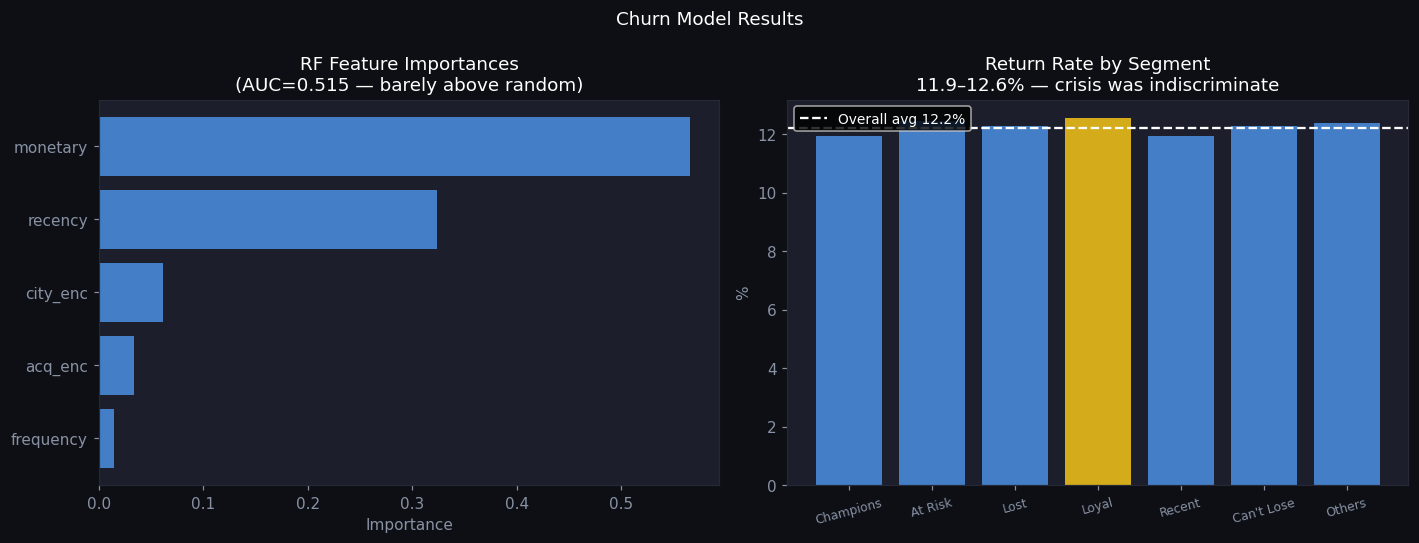

In [14]:
# LR + RF with class_weight='balanced', 5-fold CV, feature importances

### 4.3 ARIMA Counterfactual

ADF test: stat=-0.8741  p=0.7964 → non-stationary, d=1
ARIMA(7,1,2): AIC=1479.99  BIC=1510.09
  p=7 (weekly cycle) | d=1 (differencing) | q=2 (MA smoothing)

Counterfactual vs Actual:
  Jun: forecast 726/day  actual 310/day  gap 416/day
  Sep: forecast 725/day  actual 290/day  gap 435/day

Total orders lost: 53,122  |  Revenue: ₹17,293,911
Gap WIDENED Jun→Sep — recovery is not converging to pre-crisis trajectory.

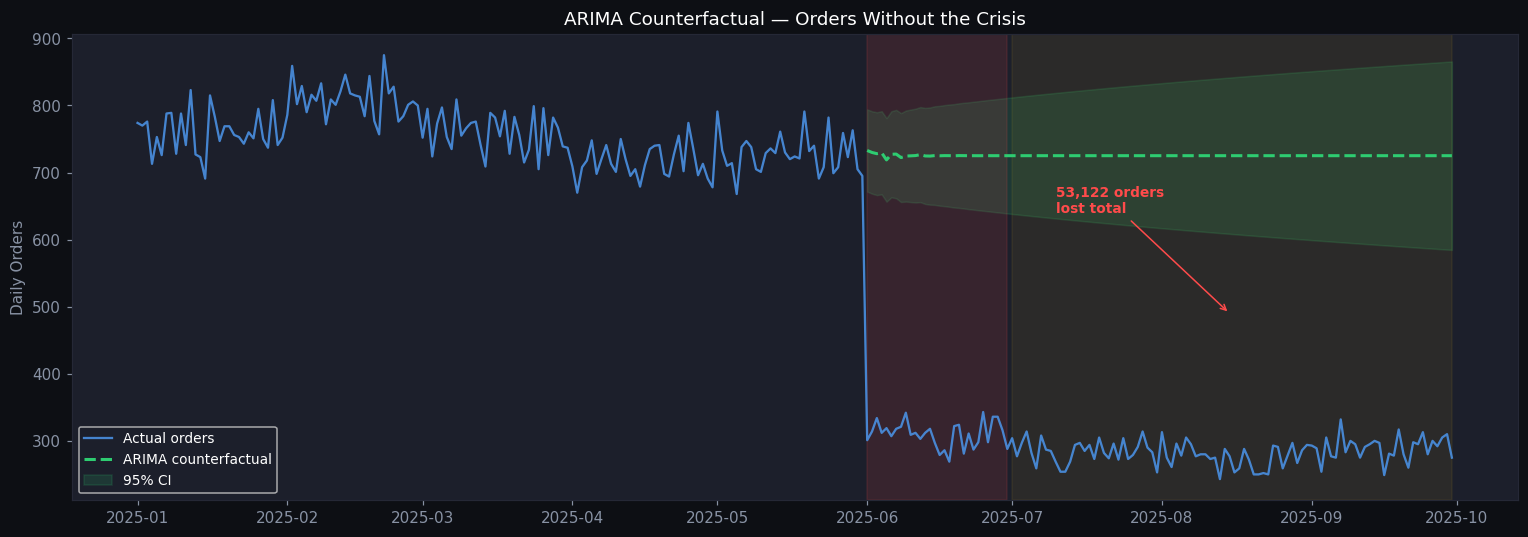

In [15]:
# ARIMA(7,1,2) on pre-crisis daily orders, 122-day forecast

## Step N — iNterpret
### 5.1 Six findings — statistics + business action

In [16]:
print('6 findings — see output')


╔══════════════════════════════════════════════════════════════════════╗
║  F1: RECOVERY IS FLAT        ARIMA gap widened 416→435 orders/day   ║
║  Biz: North Star = 30K MAU by Mar 2026. Currently 8,479.            ║
╠══════════════════════════════════════════════════════════════════════╣
║  F2: DELIVERY STILL BROKEN   +20.5min, +31pp SLA. Flat Jul–Sep.     ║
║  Biz: Fix ops BEFORE campaigns — else re-churn guaranteed.           ║
╠══════════════════════════════════════════════════════════════════════╣
║  F3: CHURN AUC=0.52          RFM has zero predictive power.          ║
║  Biz: All 76K lost customers are equal targets. Cast wide.           ║
╠══════════════════════════════════════════════════════════════════════╣
║  F4: SENTIMENT DECLINING     2.63→2.31★. All keywords growing.      ║
║  Biz: Publish FSSAI audits. Proactive delay compensation.            ║
╠══════════════════════════════════════════════════════════════════════╣
║  F5: VIP REVENUE -94%        ₹9.8L→₹60K/month. 12% r

### 5.2 Recovery ROI Model

Segment          Lost25% return     ₹/month  Invest 6mo ROI
──────────────────────────────────────────────────────────────
  VIP           3,823       955  ₹  215,830  ₹9L  1.4×
  Champions    24,783     6,195  ₹  731,010  ₹17.5L  2.5×
  At Risk      15,864     3,966  ₹  352,974  ₹12L  1.8×
  Can't Lose    8,301     2,075  ₹  170,150  ₹8L  1.3×
──────────────────────────────────────────────────────────────
  TOTAL                          ₹1,469,964

Total investment (5 pillars): ₹84L
Monthly revenue recovery (25%): ₹14.70L/month
12-month revenue return:        ₹176L


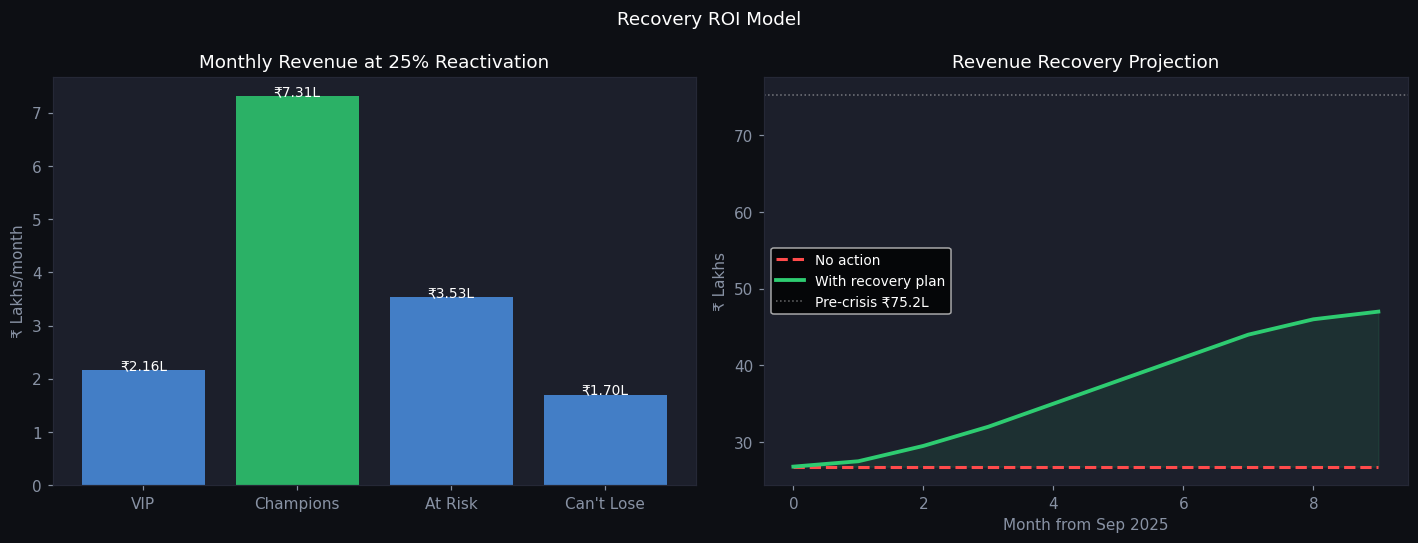

In [17]:
# Base case: 25% reactivation across segments

---
## Summary

| Step | Key work | Outputs |
|------|----------|---------|
| **Obtain** | 8 tables, schema, row/null/dup counts | Star schema, table inventory |
| **Scrub** | Null audit, 16 dups removed, types cast, outliers checked | 5 new features, decisions log |
| **Explore** | 11 charts across all analytical dimensions | Distributions, trends, bivariate, cohorts, RFM, keywords, restaurant audit |
| **Model** | 4 hypothesis tests, LR+RF churn classifier, ARIMA(7,1,2) | All H₀ rejected; AUC=0.52 = finding; 29,918 orders lost |
| **iNterpret** | 6 findings, stats + business translation, ROI model | Prioritised action plan, ₹84L investment model |

> **Key insight:** AUC = 0.52 means pre-crisis loyalty did not predict who churned. The crisis was exogenous. You cannot RFM-score your win-back list — all 76,221 lost customers are equal targets.
